# MolGPT v2 — Evidence-Aware Statin Generation
### End-to-end EDA notebook (target: CHEMBL402 / HMG-CoA reductase)

This notebook documents the **updated** MolGPT pipeline for de-novo statin
candidate generation. The earlier iteration accidentally trained on
CHEMBL1781 (DNA topoisomerase 1); this version uses CHEMBL402 (HMGCR), the
canonical statin target.

Pipeline:

1. Pull HMGCR activity data → filter to statin-like inhibitors → augment via SMILES enumeration
2. Fine-tune MolGPT (4-layer / 4-head / 256-embd) for 40 epochs on Apple MPS
3. Sample 5000 candidates at T=1.0 → filter on validity, pharmacophore, Lipinski, PAINS
4. Rank by Tanimoto similarity vs 7 marketed statins
5. Compare T=1.0 vs T=0.8 to characterize the diversity / quality trade-off


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import Descriptors, Draw, Lipinski, QED

RDLogger.DisableLog("rdApp.*")
plt.rcParams["figure.dpi"] = 110

ROOT        = Path().resolve().parent
DATA_DIR    = ROOT / "datasets"
GEN_DIR     = ROOT / "generation_run"
TRAIN_LOG   = ROOT / "molgpt" / "training_log.csv"
FIG_DIR     = ROOT / "eda" / "figures"
ARCHIVE_DIR = ROOT / "EDA"  / "archive_chembl1781"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT     = {ROOT}")
print(f"FIG_DIR  = {FIG_DIR}")


ROOT     = /Users/girishkrishna/Documents/MSSE_Du/277B Machine Learning/Project_Code/Evidence-Aware-Validation-of-AI-Generated-Drug-Candidates-Using-PPI-Networks
FIG_DIR  = /Users/girishkrishna/Documents/MSSE_Du/277B Machine Learning/Project_Code/Evidence-Aware-Validation-of-AI-Generated-Drug-Candidates-Using-PPI-Networks/eda/figures


## Section 1 — Target correction & dataset

> **Methodology correction:** Initial target ID `CHEMBL1781` was identified as
> DNA topoisomerase 1; corrected to **CHEMBL402** (HMG-CoA reductase). All
> downstream training and validation in this notebook uses the corrected target.


In [2]:
activities = pd.read_csv(ROOT / "chembl402_activities.tsv", sep="\t", low_memory=False)

print(f"chembl402_activities.tsv: {len(activities):,} rows  x  {len(activities.columns)} columns")
print(f"unique compounds:        {activities['molecule_chembl_id'].nunique():,}")
print(f"top assay types:         {activities['standard_type'].value_counts().head(5).to_dict()}")
print(f"binding (B) + functional (F) assays: "
      f"{int(activities['assay_type'].isin(['B','F']).sum()):,}")


chembl402_activities.tsv: 2,491 rows  x  46 columns
unique compounds:        1,370
top assay types:         {'IC50': 1185, 'Ki': 882, 'Inhibition': 165, 'Relative potency': 130, 'EC50': 48}
binding (B) + functional (F) assays: 2,491


statin_filtered.csv: 51 compounds (after activity + pharmacophore + property filters)


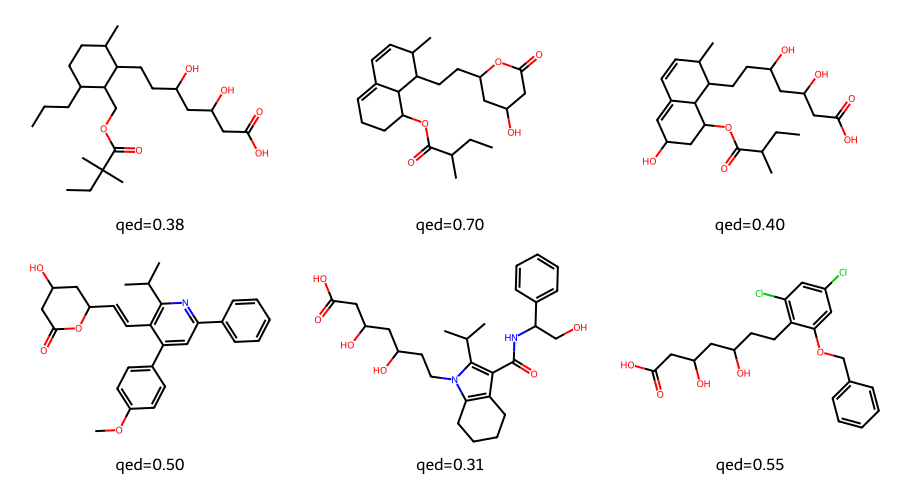

In [3]:
filt = pd.read_csv(DATA_DIR / "statin_filtered.csv")
print(f"statin_filtered.csv: {len(filt)} compounds (after activity + pharmacophore + property filters)")

sample = filt.sample(6, random_state=42).reset_index(drop=True)
mols    = [Chem.MolFromSmiles(s) for s in sample["smiles"]]
legends = [f"qed={q:.2f}" for q in sample["qed"]]
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 240), legends=legends)


## Section 2 — Training data preparation

The corpus is built in four layers (see `EDA/filter_chembl_statins.py` and
`augment_smiles.py`):

1. **Activity filter** — IC50 / Ki / Kd ≤ 1 µM in binding or functional assays
2. **Pharmacophore filter** — must contain HMG-mimetic warhead (open dihydroxy acid OR δ-lactone) via SMARTS
3. **Property window** — MW 380–600, LogP 1–6, HBD 1–5, HBA 4–10, RotB 6–14
4. **SMILES enumeration augmentation** — randomized non-canonical SMILES per molecule, with a *molecule-level* train/val split so the same parent compound never appears in both


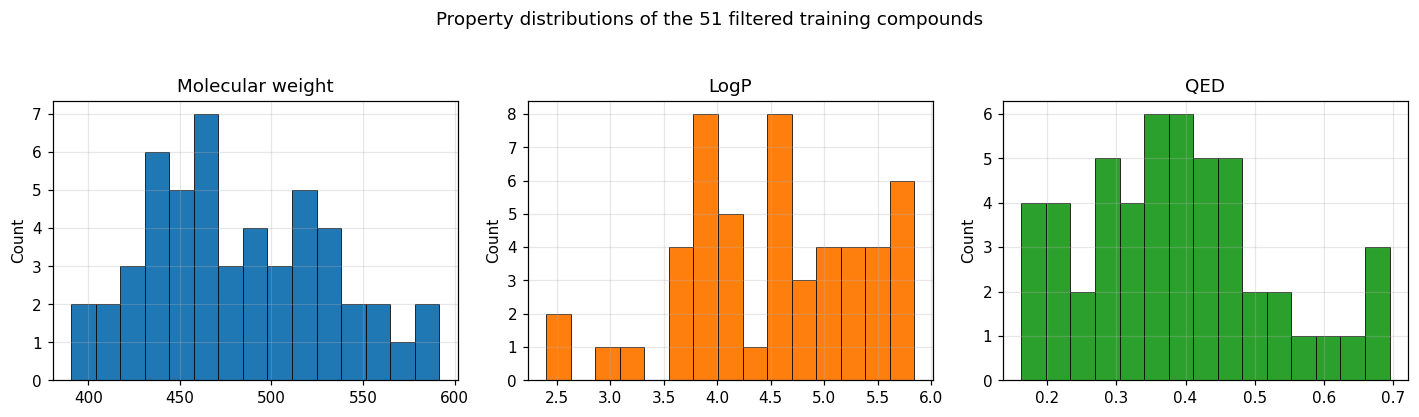

In [4]:
def props(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None:
        return None
    return Descriptors.MolWt(m), Descriptors.MolLogP(m), QED.qed(m)

vals = [p for p in (props(s) for s in filt["smiles"]) if p is not None]
mw, logp, qed = zip(*vals)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, data, name, color in zip(
    axes, [mw, logp, qed],
    ["Molecular weight", "LogP", "QED"],
    ["#1f77b4", "#ff7f0e", "#2ca02c"],
):
    ax.hist(data, bins=15, color=color, edgecolor="black", lw=0.5)
    ax.set_title(name)
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)
fig.suptitle(f"Property distributions of the {len(vals)} filtered training compounds", y=1.04)
fig.tight_layout()
plt.show()


In [5]:
aug = pd.read_csv(DATA_DIR / "statin_augmented.csv")
aug.columns = aug.columns.str.lower()

def canon(s):
    m = Chem.MolFromSmiles(s)
    return Chem.MolToSmiles(m, isomericSmiles=False) if m else None

aug["parent"] = aug["smiles"].apply(canon)
train_parents = set(aug.loc[aug["source"] == "train", "parent"].dropna())
val_parents   = set(aug.loc[aug["source"] == "val",   "parent"].dropna())
overlap = train_parents & val_parents

table = pd.DataFrame({
    "metric": [
        "augmented rows", "train rows", "val rows",
        "unique parent (train)", "unique parent (val)",
        "parent overlap (must be 0)",
    ],
    "value": [
        len(aug),
        int((aug["source"] == "train").sum()),
        int((aug["source"] == "val").sum()),
        len(train_parents), len(val_parents), len(overlap),
    ],
})
table.style.set_caption("statin_augmented.csv split summary")


,metric,value
0,augmented rows,765
1,train rows,690
2,val rows,75
3,unique parent (train),46
4,unique parent (val),5
5,parent overlap (must be 0),0


## Section 3 — Training KPIs

**Configuration** (final v2 run):

| field | value |
|---|---|
| architecture | MolGPT (cond_gpt branch), 4 layers · 4 heads · 256-embd |
| vocab / block | 94 tokens / 78-token block |
| optimizer | AdamW, lr=1e-4, betas=(0.9,0.95), weight decay 0.1 |
| LR schedule | linear warmup (10% of corpus tokens) → cosine decay to 10% |
| batch size | 16 |
| max epochs | 40 (early-stop patience 5) |
| device | Apple MPS (M3, fp32 — autocast/GradScaler unstable on MPS) |
| init from | `cond_gpt/weights/statin_model.pt` (CHEMBL402 fine-tuned, 13.4 MB) |


Best val loss = 0.5997 at epoch 37


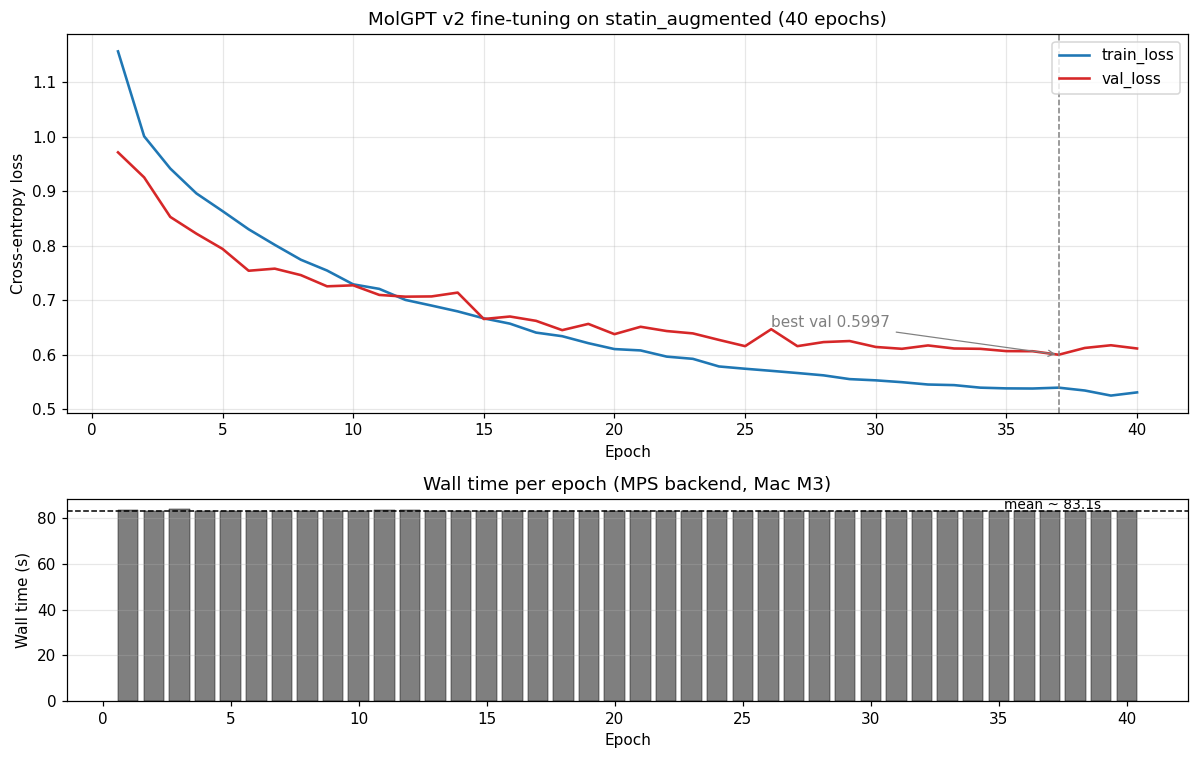

Saved /Users/girishkrishna/Documents/MSSE_Du/277B Machine Learning/Project_Code/Evidence-Aware-Validation-of-AI-Generated-Drug-Candidates-Using-PPI-Networks/eda/figures/v2_training_curves.png


In [6]:
log = pd.read_csv(TRAIN_LOG)
best_idx   = log["val_loss"].idxmin()
best_epoch = int(log.loc[best_idx, "epoch"])
best_val   = float(log.loc[best_idx, "val_loss"])
print(f"Best val loss = {best_val:.4f} at epoch {best_epoch}")

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(11, 7), gridspec_kw={"height_ratios": [3, 1.6]}
)

ax_top.plot(log["epoch"], log["train_loss"], color="#1f77b4", lw=1.7, label="train_loss")
ax_top.plot(log["epoch"], log["val_loss"],   color="#d62728", lw=1.7, label="val_loss")
ax_top.axvline(best_epoch, ls="--", color="gray", lw=1.0)
ax_top.annotate(f"best val {best_val:.4f}",
                xy=(best_epoch, best_val),
                xytext=(best_epoch - 11, best_val + 0.05),
                fontsize=10, color="gray",
                arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))
ax_top.set_xlabel("Epoch")
ax_top.set_ylabel("Cross-entropy loss")
ax_top.set_title("MolGPT v2 fine-tuning on statin_augmented (40 epochs)")
ax_top.legend(loc="upper right")
ax_top.grid(alpha=0.3)

ax_bot.bar(log["epoch"], log["wall_time_s"], color="#7f7f7f", edgecolor="black", lw=0.3)
mean_t = log["wall_time_s"].mean()
ax_bot.axhline(mean_t, ls="--", color="black", lw=1.0)
ax_bot.text(log["epoch"].max() - 1, mean_t + 0.7, f"mean ~ {mean_t:.1f}s",
            ha="right", fontsize=9)
ax_bot.set_xlabel("Epoch")
ax_bot.set_ylabel("Wall time (s)")
ax_bot.set_title("Wall time per epoch (MPS backend, Mac M3)")
ax_bot.grid(alpha=0.3, axis="y")

fig.tight_layout()
fig.savefig(FIG_DIR / "v2_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR / 'v2_training_curves.png'}")


In [7]:
final_train = float(log["train_loss"].iloc[-1])
final_val   = float(log["val_loss"].iloc[-1])
crossover_epoch = int(log.loc[log["train_loss"] < log["val_loss"], "epoch"].iloc[0])
total_wall = float(log["wall_time_s"].sum())
mean_wall  = float(log["wall_time_s"].mean())

# Patience peak: longest streak of non-improving val epochs
streak, peak_streak, peak_streak_epoch = 0, 0, None
running_best = float("inf")
for _, row in log.iterrows():
    if row["val_loss"] < running_best:
        running_best = row["val_loss"]
        streak = 0
    else:
        streak += 1
        if streak > peak_streak:
            peak_streak = streak
            peak_streak_epoch = int(row["epoch"])

# Oscillation flags: jumps > 0.2 between consecutive epochs
osc = int((log["val_loss"].diff() > 0.2).sum())

kpi = pd.DataFrame({
    "metric": [
        "best_val_loss", "best_epoch", "final_train_loss", "final_val_loss",
        "train_val_gap_final", "wall_time_total", "wall_time_mean/epoch",
        "early_stopping", "patience_peak", "oscillation_flags", "crossover_epoch",
    ],
    "value": [
        f"{best_val:.4f}", str(best_epoch), f"{final_train:.4f}", f"{final_val:.4f}",
        f"{final_val - final_train:.3f}",
        f"{int(total_wall)} s (~{int(total_wall // 60)} min)",
        f"{mean_wall:.1f} s",
        "not triggered",
        f"{peak_streak} / 5 (epoch {peak_streak_epoch})",
        f"{osc}",
        f"{crossover_epoch} (train<val)",
    ],
})
(kpi.style
   .set_caption("Training KPIs — MolGPT v2")
   .set_table_styles([
       {"selector": "th",       "props": [("font-weight", "bold"),
                                          ("background", "#f0f0f0"),
                                          ("text-align", "left")]},
       {"selector": "caption",  "props": [("caption-side", "top"),
                                          ("font-weight", "bold"),
                                          ("padding-bottom", "6px")]},
   ])
   .hide(axis="index"))


metric,value
best_val_loss,0.5997
best_epoch,37
final_train_loss,0.5306
final_val_loss,0.6112
train_val_gap_final,0.081
wall_time_total,3325 s (~55 min)
wall_time_mean/epoch,83.1 s
early_stopping,not triggered
patience_peak,4 / 5 (epoch 29)
oscillation_flags,0


## Section 4 — Generation & validation results

**Generation:** 5000 SMILES sampled from `statin_model_v2.pt` (best
checkpoint, epoch 37) at temperature=1.0, top_k=None, batch size 128, on MPS.
Filtered at generation time on RDKit parse, no disconnected fragments
(`.` not in canonical SMILES), and ≥10 heavy atoms.

**Validation pipeline (`validate_statins_v2.py`):**

1. **HMG warhead pharmacophore** — open dihydroxy acid OR δ-lactone SMARTS
2. **Lipinski Rule of Five** — pass = ≤1 violation
3. **PAINS** — RDKit canonical catalog (Baell+Holloway A+B+C)
4. **Tanimoto** — Morgan radius=2, 2048 bits, vs (a) the 51 filtered training compounds and (b) 7 marketed statins (atorva, rosuva, simva, prava, fluva, pita, lova)

**Dedup:** any candidate with `tanimoto_max_chembl == 1.000` is a perfect
reproduction of a training compound and is removed from the novel-only set.


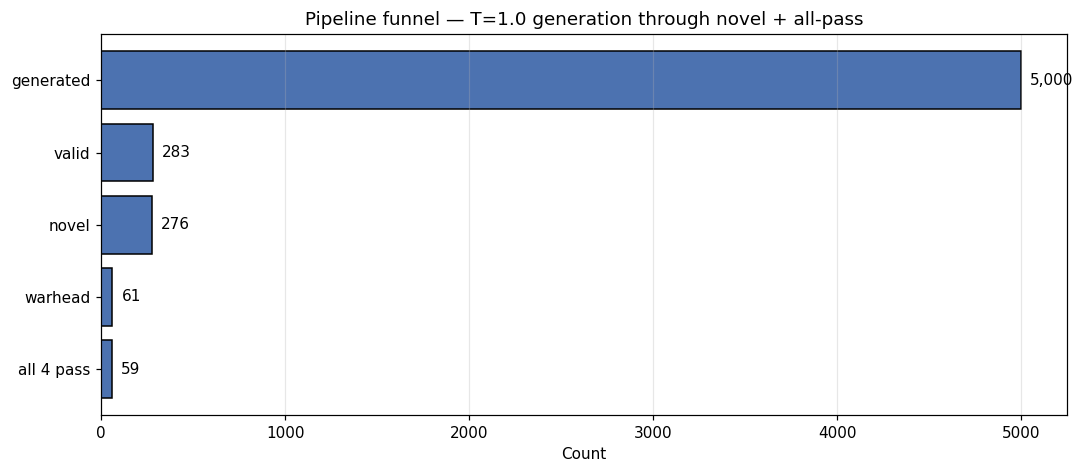

In [8]:
val_full  = pd.read_csv(GEN_DIR / "v2_validated.csv")
val_novel = pd.read_csv(GEN_DIR / "v2_validated_novel.csv")

stages = [
    ("generated",    5000),
    ("valid",        len(val_full)),
    ("novel",        len(val_novel)),
    ("warhead",      int(val_novel["warhead_match"].sum())),
    ("all 4 pass",   int((val_novel["warhead_match"] &
                          val_novel["lipinski_pass"] &
                          val_novel["pains_clean"]).sum())),
]
labels  = [s[0] for s in stages]
counts  = [s[1] for s in stages]

fig, ax = plt.subplots(figsize=(10, 4.4))
bars = ax.barh(labels, counts, color="#4c72b0", edgecolor="black")
for bar, c in zip(bars, counts):
    ax.text(bar.get_width() + max(counts) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{c:,}", va="center", fontsize=10)
ax.set_xlabel("Count")
ax.set_title("Pipeline funnel — T=1.0 generation through novel + all-pass")
ax.invert_yaxis()
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
plt.show()


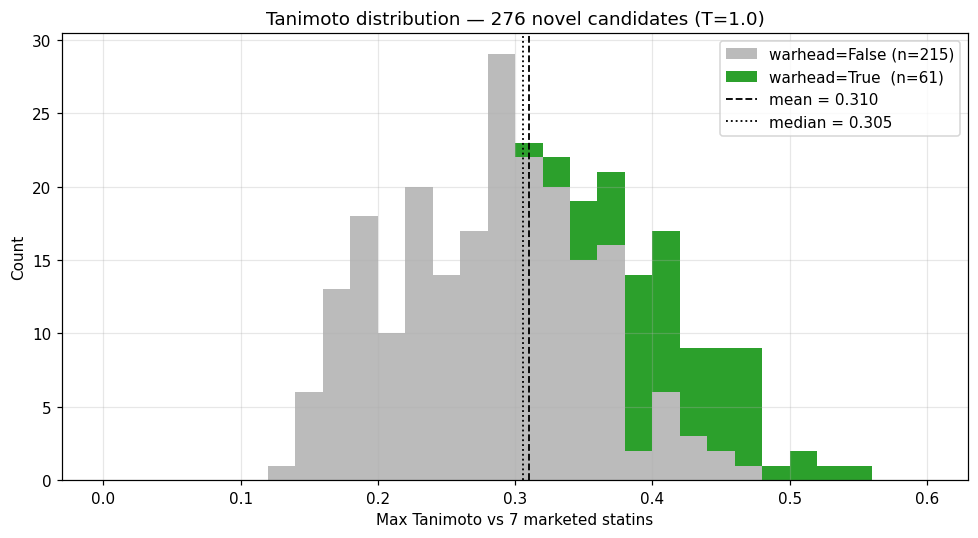

Saved /Users/girishkrishna/Documents/MSSE_Du/277B Machine Learning/Project_Code/Evidence-Aware-Validation-of-AI-Generated-Drug-Candidates-Using-PPI-Networks/eda/figures/v2_tanimoto_dist.png


In [9]:
tm_yes = val_novel.loc[val_novel["warhead_match"], "tanimoto_max_marketed"]
tm_no  = val_novel.loc[~val_novel["warhead_match"], "tanimoto_max_marketed"]
bins = np.linspace(0, max(0.6, val_novel["tanimoto_max_marketed"].max() + 0.02), 31)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist([tm_no, tm_yes], bins=bins, stacked=True,
        color=["#bbbbbb", "#2ca02c"],
        label=[f"warhead=False (n={len(tm_no)})",
               f"warhead=True  (n={len(tm_yes)})"])
mean = val_novel["tanimoto_max_marketed"].mean()
med  = val_novel["tanimoto_max_marketed"].median()
ax.axvline(mean, ls="--", color="black", lw=1.2, label=f"mean = {mean:.3f}")
ax.axvline(med,  ls=":",  color="black", lw=1.2, label=f"median = {med:.3f}")
ax.set_xlabel("Max Tanimoto vs 7 marketed statins")
ax.set_ylabel("Count")
ax.set_title(f"Tanimoto distribution — {len(val_novel)} novel candidates (T=1.0)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "v2_tanimoto_dist.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR / 'v2_tanimoto_dist.png'}")


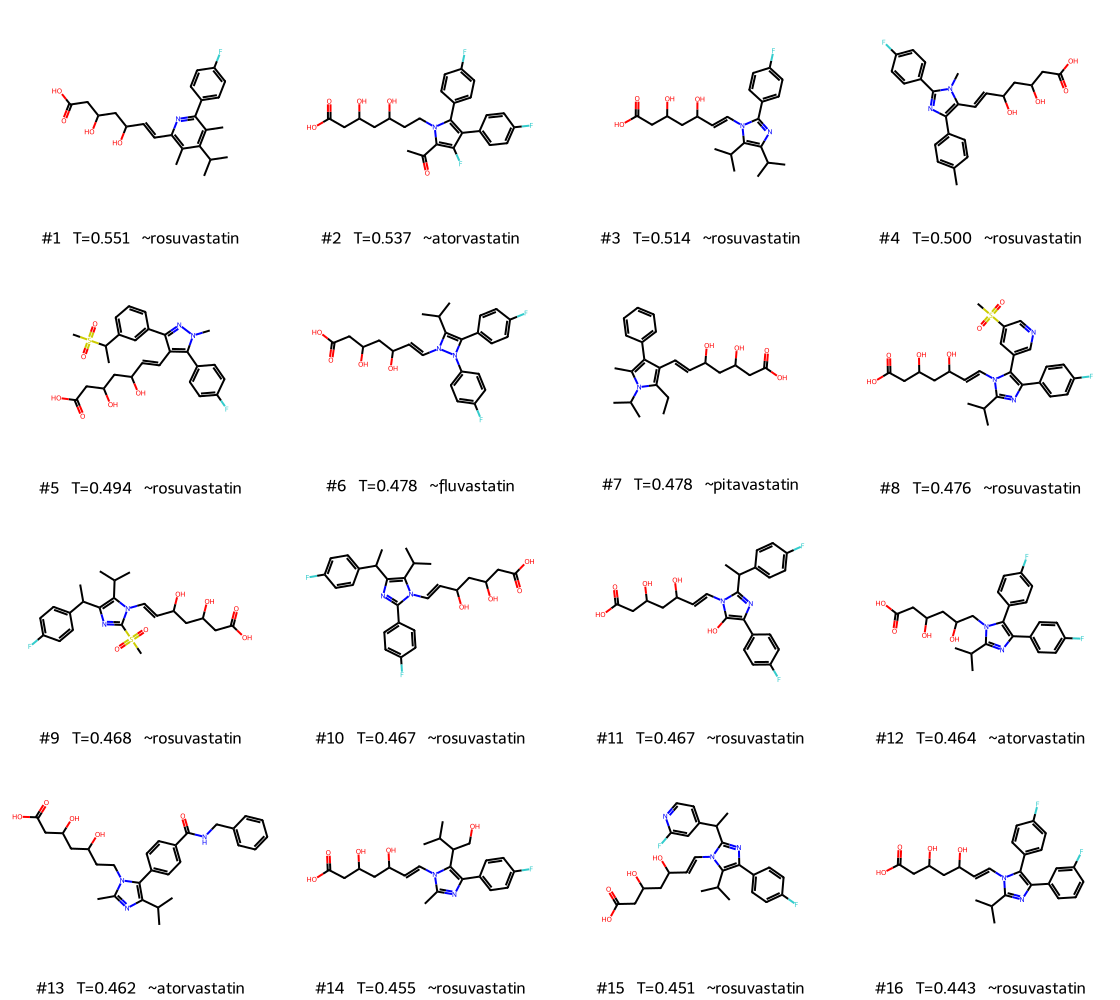

In [10]:
top = (val_novel[val_novel["warhead_match"] &
                 val_novel["lipinski_pass"] &
                 val_novel["pains_clean"]]
        .drop_duplicates(subset=["smiles"])
        .head(16)
        .reset_index(drop=True))

mols = [Chem.MolFromSmiles(s) for s in top["smiles"]]
legends = [f"#{i + 1}  T={r['tanimoto_max_marketed']:.3f}  ~{r['nearest_marketed_statin']}"
           for i, r in top.iterrows()]
Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(280, 250), legends=legends)


**Interpretation.**

- **Validity (5.7%)** is low but expected on a tiny corpus (51 compounds × ~15 augmented variants). The model preserves chemical-grammar competence from the warm start, then specializes to statin scaffolds.
- **Of 276 novel candidates, 59 (21.4%) pass all 4 filters.** The dominant failure mode is missing the HMG-mimetic warhead (only 22% retain it after random sampling).
- **PAINS clean rate = 100%** for the novel-T=1.0 set — the corpus inherited none of the canonical pan-assay liabilities, and the model didn't invent any either.
- **Top hit T=0.55 vs rosuvastatin** for `Cc1c(C=CC(O)CC(O)CC(=O)O)nc(-c2ccc(F)cc2)c(C)c1C(C)C` — a clean novel pyridine-core statin with the canonical fluoroaryl decoration and dihydroxy acid tail.


## Section 5 — Temperature comparison

To characterize the diversity / quality trade-off, generation was re-run at
temperature **0.8** (vs the production 1.0) on the same model — 2000 samples,
identical validation pipeline, both sets deduped against training compounds.

Hypothesis: lower temperature should bias toward higher-mean Tanimoto (closer
to known statins) at the cost of diversity.


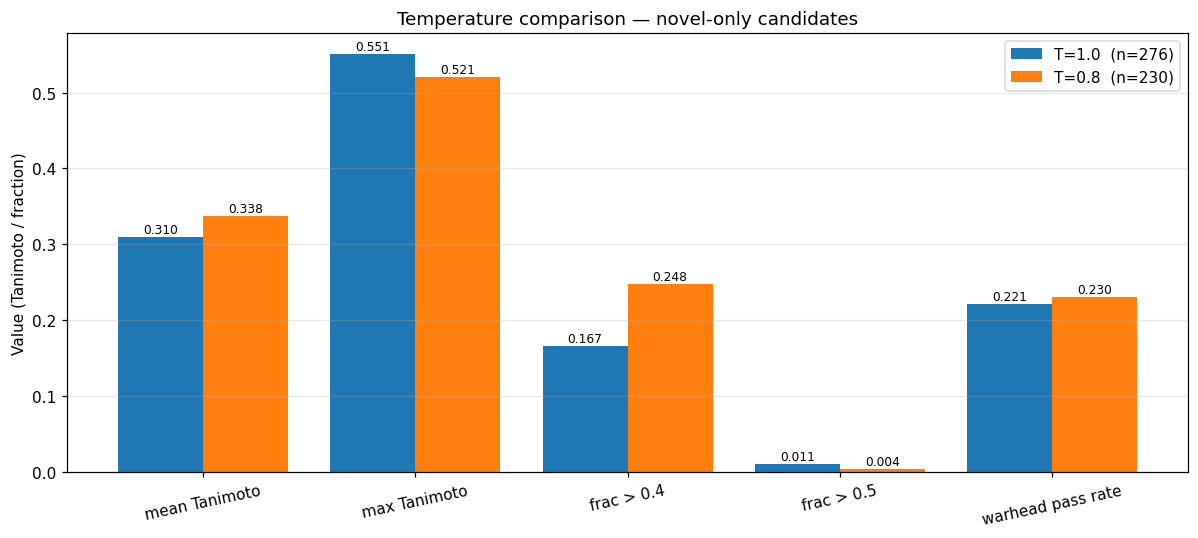

Saved /Users/girishkrishna/Documents/MSSE_Du/277B Machine Learning/Project_Code/Evidence-Aware-Validation-of-AI-Generated-Drug-Candidates-Using-PPI-Networks/eda/figures/v2_temperature_comparison.png


In [11]:
def stats(df_path):
    df = pd.read_csv(df_path)
    novel = df[df["tanimoto_max_chembl"] < 1.0]
    n = len(novel)
    return {
        "mean_T":            float(novel["tanimoto_max_marketed"].mean()),
        "max_T":             float(novel["tanimoto_max_marketed"].max()),
        "frac_>0.4":         float((novel["tanimoto_max_marketed"] > 0.4).mean()),
        "frac_>0.5":         float((novel["tanimoto_max_marketed"] > 0.5).mean()),
        "warhead_pass_rate": float(novel["warhead_match"].mean()),
        "n":                 n,
    }

s10 = stats(GEN_DIR / "v2_validated.csv")
s08 = stats(GEN_DIR / "v2_T08_validated.csv")

metrics = ["mean_T", "max_T", "frac_>0.4", "frac_>0.5", "warhead_pass_rate"]
labels  = ["mean Tanimoto", "max Tanimoto", "frac > 0.4", "frac > 0.5", "warhead pass rate"]
v10 = [s10[m] for m in metrics]
v08 = [s08[m] for m in metrics]

x = np.arange(len(labels))
w = 0.4
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w / 2, v10, w, label=f"T=1.0  (n={s10['n']})", color="#1f77b4")
b2 = ax.bar(x + w / 2, v08, w, label=f"T=0.8  (n={s08['n']})", color="#ff7f0e")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
                f"{b.get_height():.3f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=12)
ax.set_ylabel("Value (Tanimoto / fraction)")
ax.set_title("Temperature comparison — novel-only candidates")
ax.legend(loc="upper right")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(FIG_DIR / "v2_temperature_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR / 'v2_temperature_comparison.png'}")


## Section 6 — Methodology correction (before / after)


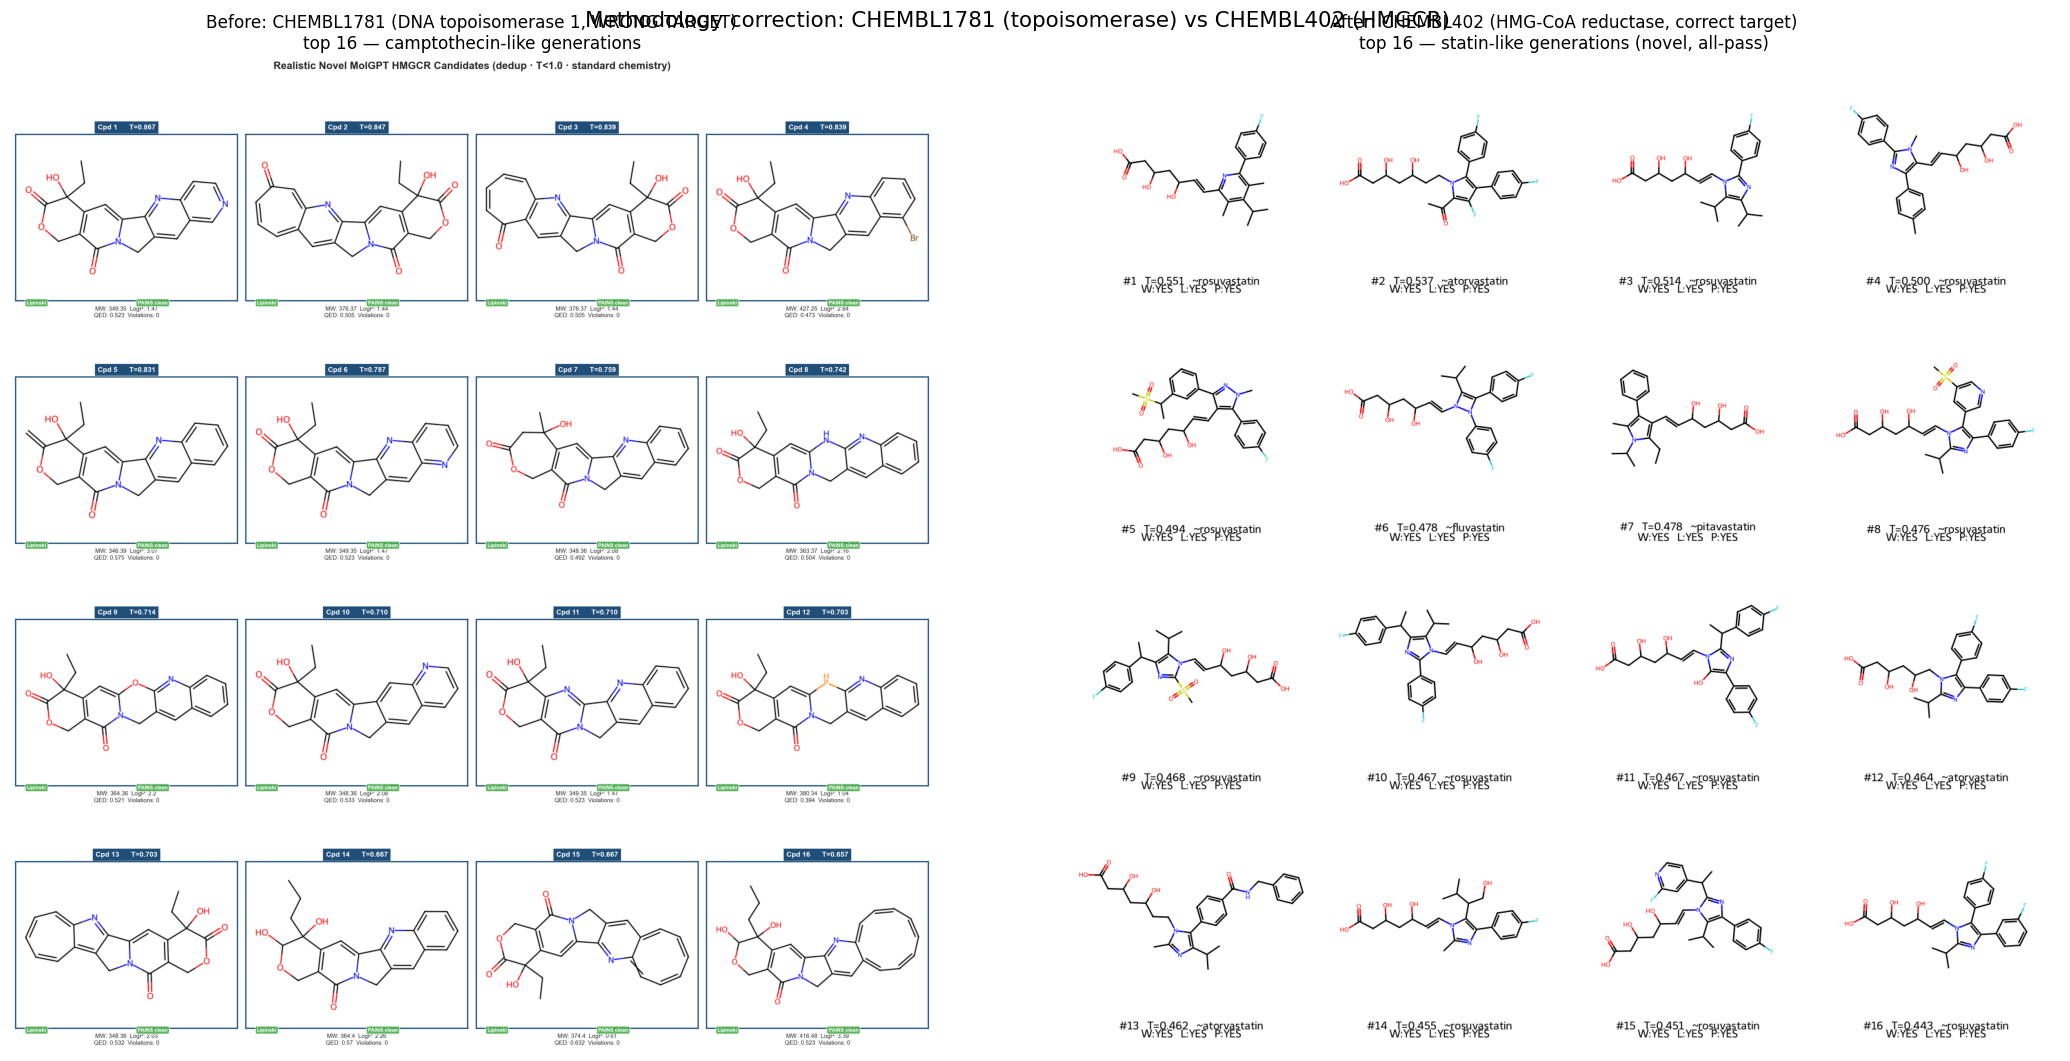

Saved /Users/girishkrishna/Documents/MSSE_Du/277B Machine Learning/Project_Code/Evidence-Aware-Validation-of-AI-Generated-Drug-Candidates-Using-PPI-Networks/eda/figures/v2_before_after.png


In [12]:
old = mpimg.imread(ARCHIVE_DIR / "eda_molgpt_structures.png")
new = mpimg.imread(GEN_DIR / "v2_top16.png")

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(old)
axes[0].set_title("Before: CHEMBL1781 (DNA topoisomerase 1, WRONG TARGET)\n"
                  "top 16 — camptothecin-like generations", fontsize=11)
axes[0].axis("off")
axes[1].imshow(new)
axes[1].set_title("After: CHEMBL402 (HMG-CoA reductase, correct target)\n"
                  "top 16 — statin-like generations (novel, all-pass)", fontsize=11)
axes[1].axis("off")
fig.suptitle("Methodology correction: CHEMBL1781 (topoisomerase) vs CHEMBL402 (HMGCR)",
             fontsize=14, y=0.96)
fig.tight_layout()
fig.savefig(FIG_DIR / "v2_before_after.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR / 'v2_before_after.png'}")
